# Comparação de trajetórias — Odometria vs Dead Reckoning

Este notebook carrega automaticamente os arquivos `gt.csv`, `odo.csv`, `dr.csv` e `odo_husky.csv` a partir de uma pasta de resultados.

Altere apenas a variável `PASTA_DADOS` para apontar para a pasta gerada pela simulação, por exemplo:

```python
PASTA_DADOS = Path('/home/rafael/odo_vs_dc/resultados/empty_20260503_143351')
```

Este notebook **não salva arquivos PNG automaticamente**. Ele apenas exibe os gráficos na tela.


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Altere somente esta variável para a pasta da simulação que deseja analisar.
# Exemplo de pasta gerada com timestamp:
PASTA_DADOS = Path('/home/rafael/odo_vs_dc/resultados/empty_20260504_014125')

def carregar_csv(nome):
    caminho = PASTA_DADOS / nome
    if not caminho.exists():
        raise FileNotFoundError(f'Arquivo não encontrado: {caminho}')
    return pd.read_csv(caminho, comment='#')

print(f'Lendo dados de: {PASTA_DADOS}')


Lendo dados de: /home/rafael/odo_vs_dc/resultados/empty_20260504_014125


## 1. Carregar os dados

In [9]:
gt = carregar_csv('gt.csv')
odo = carregar_csv('odo.csv')
dr = carregar_csv('dr.csv')
odo_husky = carregar_csv('odo_husky.csv')

print('Arquivos carregados:')
print(f'gt:        {len(gt)} amostras')
print(f'odo:       {len(odo)} amostras')
print(f'dr:        {len(dr)} amostras')
print(f'odo_husky: {len(odo_husky)} amostras')


Arquivos carregados:
gt:        750 amostras
odo:       750 amostras
dr:        750 amostras
odo_husky: 750 amostras


## 2. Trajetória no plano X-Y

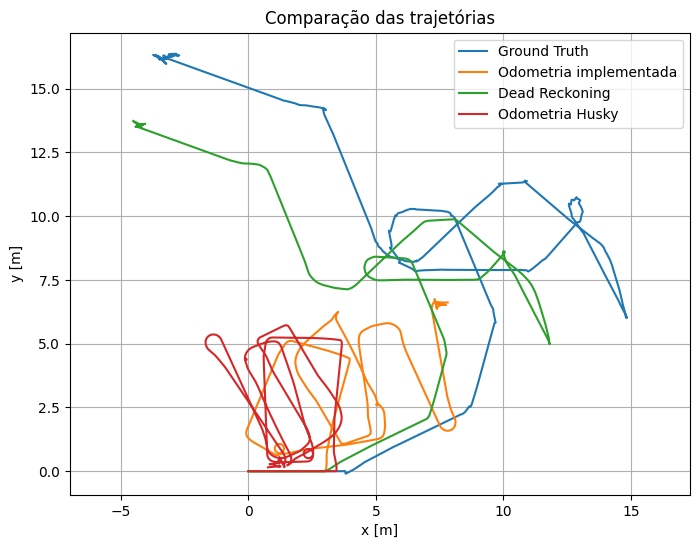

In [10]:
plt.figure(figsize=(8, 6))

plt.plot(gt['field.x'], gt['field.y'], label='Ground Truth')
plt.plot(odo['field.x'], odo['field.y'], label='Odometria implementada')
plt.plot(dr['field.x'], dr['field.y'], label='Dead Reckoning')
plt.plot(odo_husky['field.x'], odo_husky['field.y'], label='Odometria Husky')

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Comparação das trajetórias')
plt.legend()
plt.grid(True)
plt.axis('equal')

plt.show()

## 3. Posição X ao longo do tempo

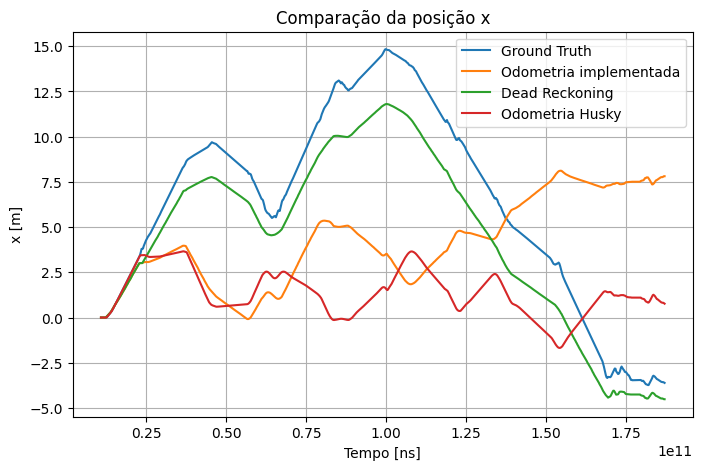

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(gt['%time'], gt['field.x'], label='Ground Truth')
plt.plot(odo['%time'], odo['field.x'], label='Odometria implementada')
plt.plot(dr['%time'], dr['field.x'], label='Dead Reckoning')
plt.plot(odo_husky['%time'], odo_husky['field.x'], label='Odometria Husky')

plt.xlabel('Tempo [ns]')
plt.ylabel('x [m]')
plt.title('Comparação da posição x')
plt.legend()
plt.grid(True)

plt.show()

## 4. Posição Y ao longo do tempo

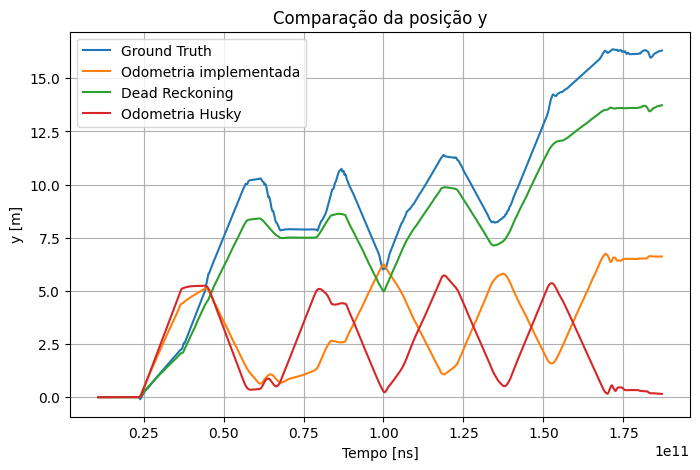

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(gt['%time'], gt['field.y'], label='Ground Truth')
plt.plot(odo['%time'], odo['field.y'], label='Odometria implementada')
plt.plot(dr['%time'], dr['field.y'], label='Dead Reckoning')
plt.plot(odo_husky['%time'], odo_husky['field.y'], label='Odometria Husky')

plt.xlabel('Tempo [ns]')
plt.ylabel('y [m]')
plt.title('Comparação da posição y')
plt.legend()
plt.grid(True)

plt.show()

## 5. Orientação θ ao longo do tempo

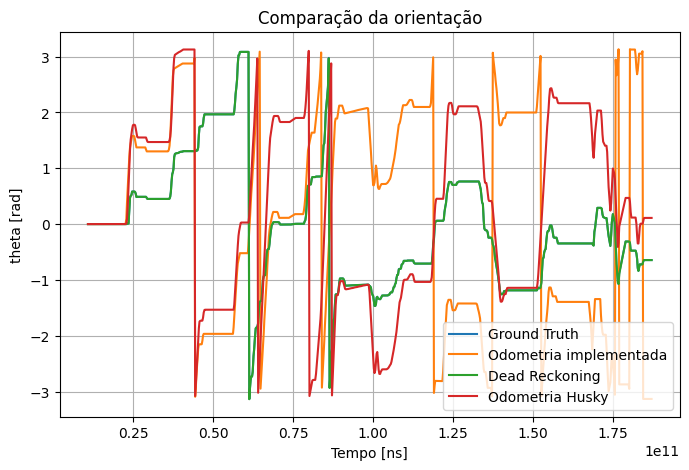

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(gt['%time'], gt['field.z'], label='Ground Truth')
plt.plot(odo['%time'], odo['field.z'], label='Odometria implementada')
plt.plot(dr['%time'], dr['field.z'], label='Dead Reckoning')
plt.plot(odo_husky['%time'], odo_husky['field.z'], label='Odometria Husky')

plt.xlabel('Tempo [ns]')
plt.ylabel('theta [rad]')
plt.title('Comparação da orientação')
plt.legend()
plt.grid(True)

plt.show()

## 6. Trajetória relativa ao ponto inicial

Remove o offset inicial de cada curva para comparar melhor o formato das trajetórias.


In [6]:
def relativo(df):
    df = df.copy()
    df["x_rel"] = df["field.x"] - df["field.x"].iloc[0]
    df["y_rel"] = df["field.y"] - df["field.y"].iloc[0]
    df["theta_rel"] = df["field.z"] - df["field.z"].iloc[0]
    return df

gt_rel = relativo(gt)
odo_rel = relativo(odo)
dr_rel = relativo(dr)
odo_husky_rel = relativo(odo_husky)

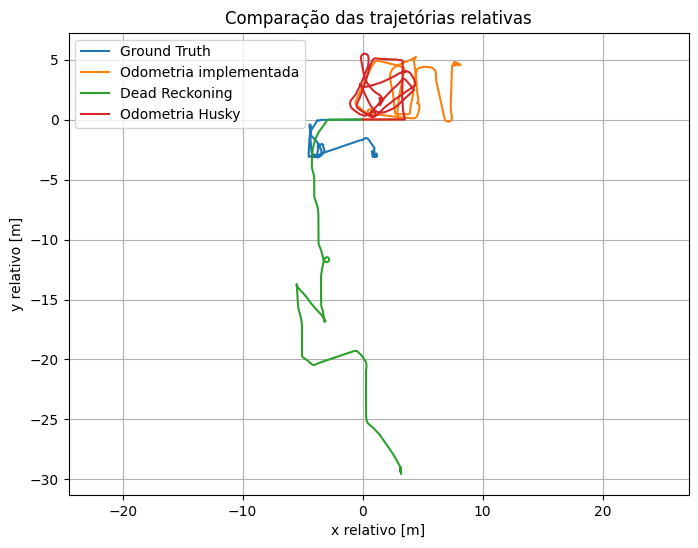

In [7]:
plt.figure(figsize=(8, 6))

plt.plot(gt_rel["x_rel"], gt_rel["y_rel"], label="Ground Truth")
plt.plot(odo_rel["x_rel"], odo_rel["y_rel"], label="Odometria implementada")
plt.plot(dr_rel["x_rel"], dr_rel["y_rel"], label="Dead Reckoning")
plt.plot(odo_husky_rel["x_rel"], odo_husky_rel["y_rel"], label="Odometria Husky")

plt.xlabel("x relativo [m]")
plt.ylabel("y relativo [m]")
plt.title("Comparação das trajetórias relativas")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

## Observação

Nos arquivos `geometry_msgs/Point`, os campos foram usados assim:

- `field.x`: posição no eixo x;
- `field.y`: posição no eixo y;
- `field.z`: orientação `theta`, em radianos.

Nesse caso, `field.z` não representa altura.

Para analisar uma nova simulação, altere apenas `PASTA_DADOS` para o caminho da nova pasta com timestamp.


## 7. Trajetória real do robô (husky_odom_log.csv)

In [77]:
import numpy as np

# Carrega odometria real do bag
odom_real = pd.read_csv('/home/rafael/odo_vs_dc/bags/husky_odom_log.csv')

# Calcula theta a partir do quaternion
qx = odom_real['field.pose.pose.orientation.x']
qy = odom_real['field.pose.pose.orientation.y']
qz = odom_real['field.pose.pose.orientation.z']
qw = odom_real['field.pose.pose.orientation.w']
odom_real['theta'] = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))

# Normaliza para começar em (0, 0)
odom_real['x_rel'] = odom_real['field.pose.pose.position.x'] - odom_real['field.pose.pose.position.x'].iloc[0]
odom_real['y_rel'] = odom_real['field.pose.pose.position.y'] - odom_real['field.pose.pose.position.y'].iloc[0]
odom_real['theta_rel'] = odom_real['theta'] - odom_real['theta'].iloc[0]

print(f'odom_real: {len(odom_real)} amostras')
print(f'posição final: x={odom_real["x_rel"].iloc[-1]:.3f} y={odom_real["y_rel"].iloc[-1]:.3f} theta={odom_real["theta_rel"].iloc[-1]:.3f}')

odom_real: 1788 amostras
posição final: x=1.983 y=0.275 theta=0.608


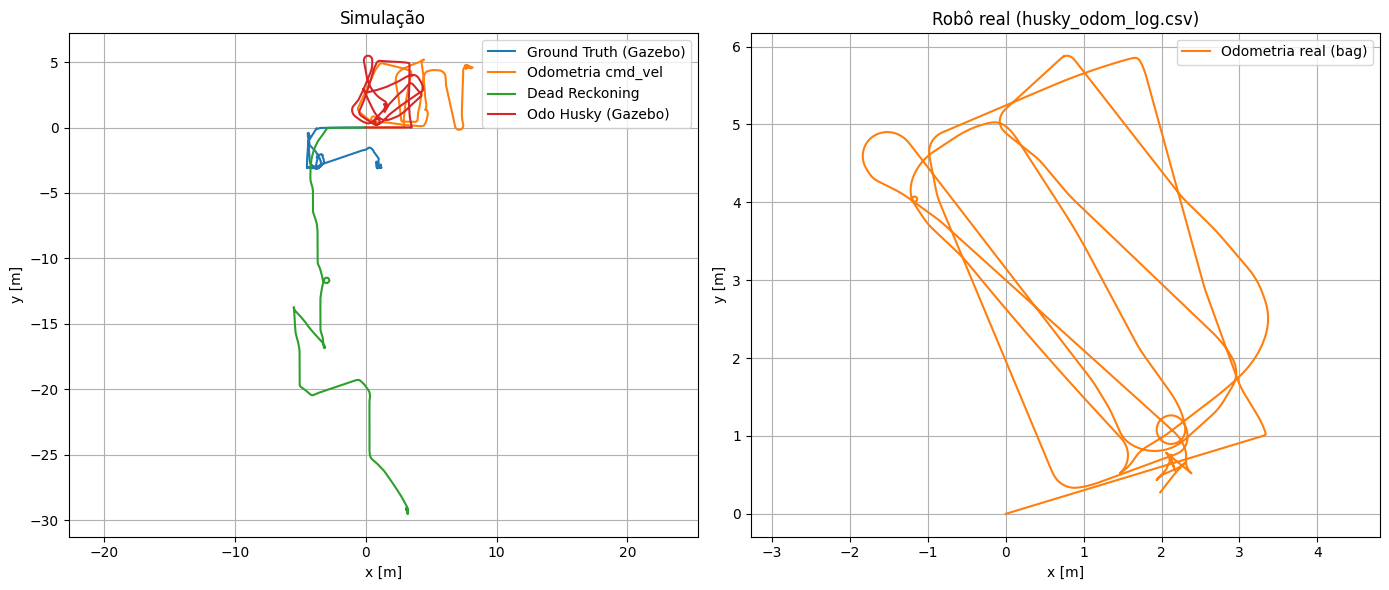

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Trajetória XY — simulação
ax = axes[0]
ax.plot(gt_rel['x_rel'],        gt_rel['y_rel'],        label='Ground Truth (Gazebo)')
ax.plot(odo_rel['x_rel'],       odo_rel['y_rel'],        label='Odometria cmd_vel')
ax.plot(dr_rel['x_rel'],        dr_rel['y_rel'],         label='Dead Reckoning')
ax.plot(odo_husky_rel['x_rel'], odo_husky_rel['y_rel'],  label='Odo Husky (Gazebo)')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Simulação')
ax.legend()
ax.grid(True)
ax.axis('equal')

# Trajetória XY — robô real
ax = axes[1]
ax.plot(odom_real['x_rel'], odom_real['y_rel'], label='Odometria real (bag)', color='tab:orange')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title('Robô real (husky_odom_log.csv)')
ax.legend()
ax.grid(True)
ax.axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(odom_real['%time'], odom_real['theta_rel'], label='Theta real (bag)')
plt.xlabel('Tempo [ns]')
plt.ylabel('theta [rad]')
plt.title('Orientação real do robô')
plt.legend()
plt.grid(True)
plt.show()